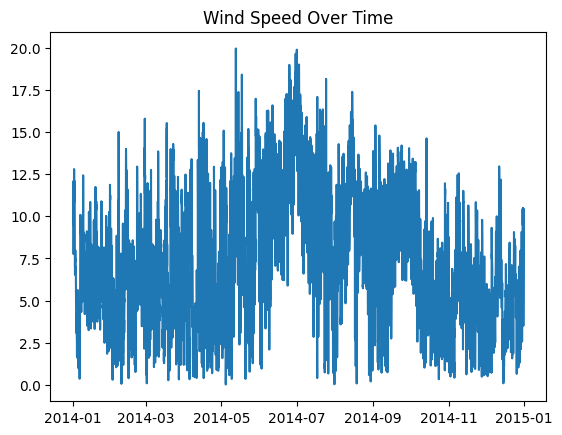

Rolling signature shape: (6108, 19, 120)
Epoch 1/200
96/96 [==============================] - 2s 10ms/step - loss: 0.1258 - val_loss: 0.0341
Epoch 2/200
96/96 [==============================] - 1s 8ms/step - loss: 0.0378 - val_loss: 0.0267
Epoch 3/200
96/96 [==============================] - 1s 8ms/step - loss: 0.0324 - val_loss: 0.0245
Epoch 4/200
96/96 [==============================] - 1s 8ms/step - loss: 0.0305 - val_loss: 0.0213
Epoch 5/200
96/96 [==============================] - 1s 8ms/step - loss: 0.0280 - val_loss: 0.0188
Epoch 6/200
96/96 [==============================] - 1s 8ms/step - loss: 0.0261 - val_loss: 0.0197
Epoch 7/200
96/96 [==============================] - 1s 8ms/step - loss: 0.0259 - val_loss: 0.0188
Epoch 8/200
96/96 [==============================] - 1s 8ms/step - loss: 0.0251 - val_loss: 0.0186
Epoch 9/200
96/96 [==============================] - 1s 8ms/step - loss: 0.0246 - val_loss: 0.0182
Epoch 10/200
96/96 [==============================] - 1s 7ms/step -

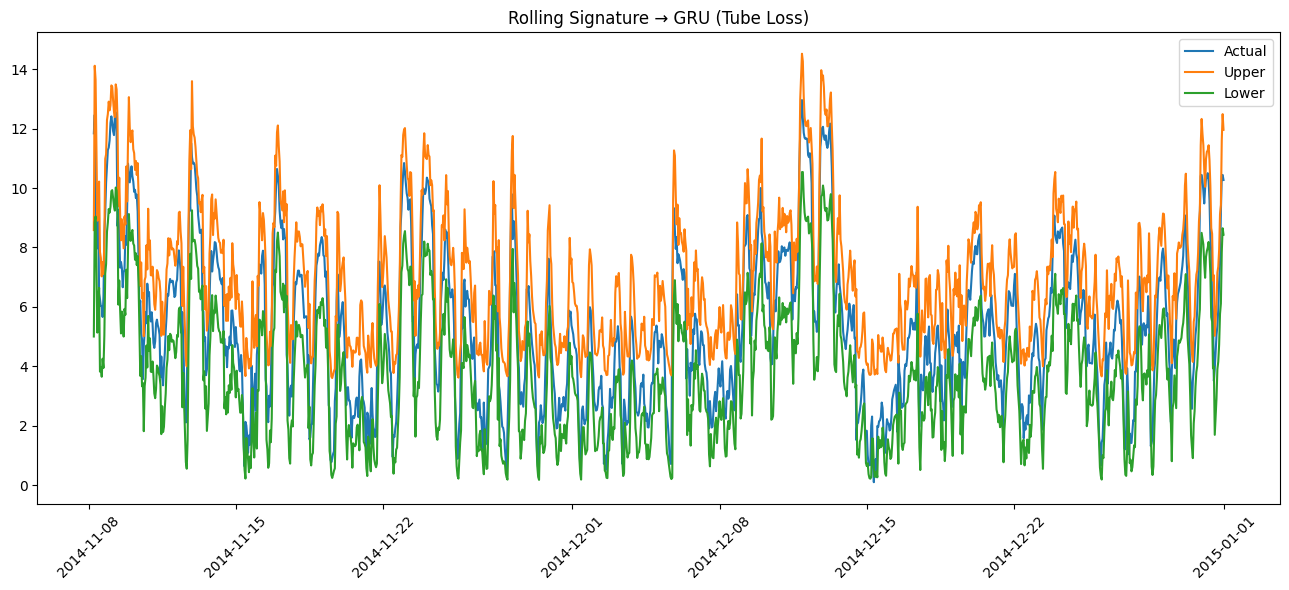

In [4]:
# ==========================================================
# LeadLag → Rolling Signatures → GRU (Tube Loss)
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import signatory
from torch import nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, TransformerMixin

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam

# ---------------------------
# 0. Reproducibility
# ---------------------------
SEED = 48
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ---------------------------
# 1. LOAD DATA
# ---------------------------
df = pd.read_csv(
    "/mnt/alpha/Research/Signature_based_UQ/dataset/Jaisalmer.csv",
    index_col="Date/Time",
    parse_dates=True
)
df = df[df.index.minute == 0]
df = pd.DataFrame({"wind": df["120m"]}, index=df.index)

plt.plot(df)
plt.title("Wind Speed Over Time")
plt.show()


# ---------------------------
# 2. TUBE / CONFIDENCE LOSS
# ---------------------------
r = 0.5
q=0.95
delta = 0.04

def confidence_loss(y_true, y_pred):
    y_true = y_true[:, 0]
    f1 = y_pred[:, 0]
    f2 = y_pred[:, 1]

    c1 = (1 - q) * (y_true - f2)
    c2 = (1 - q) * (f1 - y_true)
    c3 = q * (f2 - y_true)
    c4 = q * (y_true - f1)

    cond1 = tf.logical_and(y_true <= f1, y_true >= f2)
    cond2 = y_true > (r * f1 + (1 - r) * f2)
    cond3 = f2 > y_true

    loss = tf.where(cond1,
                    tf.where(cond2, c1, c2),
                    tf.where(cond3, c3, c4))
    return loss + delta * tf.abs(f1 - f2)


# ---------------------------
# 3. WINDOWING
# ---------------------------
input_window_size = 24
val_frac = 0.15
test_frac = 0.15

split_val = int(len(df) * (1 - val_frac - test_frac))
split_test = int(len(df) * (1 - test_frac))

train = df[:split_val]
val   = df[split_val:split_test]
test  = df[split_test:]


def make_windows(arr, win):
    X, Y = [], []
    for i in range(len(arr) - win):
        X.append(arr[i:i+win])
        Y.append(arr[i+win])
    return np.array(X), np.array(Y)


train_x, train_y = make_windows(train.values, input_window_size)
val_x,   val_y   = make_windows(val.values,   input_window_size)
test_x,  test_y  = make_windows(test.values,  input_window_size)

train_y = train_y.reshape(-1, 1)
val_y   = val_y.reshape(-1, 1)
test_y  = test_y.reshape(-1, 1)


# ---------------------------
# 4. NORMALIZATION
# ---------------------------
scaler_x = MinMaxScaler().fit(train_x.reshape(-1, 1))
scaler_y = MinMaxScaler().fit(train_y)

train_x = scaler_x.transform(train_x.reshape(-1, 1)).reshape(train_x.shape)
val_x   = scaler_x.transform(val_x.reshape(-1, 1)).reshape(val_x.shape)
test_x  = scaler_x.transform(test_x.reshape(-1, 1)).reshape(test_x.shape)

train_y_s = scaler_y.transform(train_y)
val_y_s   = scaler_y.transform(val_y)
test_y_s  = scaler_y.transform(test_y)


# ---------------------------
# 5. LEAD–LAG TRANSFORM
# ---------------------------
class LeadLag(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        Xt = torch.tensor(X, dtype=torch.float32)
        Xt = Xt.squeeze(-1).unsqueeze(-1)
        Xr = Xt.repeat_interleave(2, dim=1)
        lead = Xr[:, 1:, :]
        lag  = Xr[:, :-1, :]
        return torch.cat([lead, lag], dim=2)

leadlag = LeadLag()


# ---------------------------
# 6. SIGNATURE EXTRACTOR
# ---------------------------
class SignatureExtractor(nn.Module):
    def __init__(self, depth):
        super().__init__()
        self.signature = signatory.Signature(depth=depth)

    def forward(self, x):
        B, T, _ = x.shape
        t = torch.linspace(0, 1, T, device=x.device)
        t = t.view(1, T, 1).repeat(B, 1, 1)
        x_aug = torch.cat([x, t], dim=2)
        return self.signature(x_aug, basepoint=True)

sig_depth = 4
sig_extractor = SignatureExtractor(sig_depth).to(device).eval()


# ---------------------------
# 7. ROLLING SIGNATURE FEATURES
# ---------------------------
subwindow_size = 6
stride = 1

def extract_rolling_signatures(windows, batch_size=256):
    all_feats = []
    with torch.no_grad():
        for i in range(0, len(windows), batch_size):
            xb = windows[i:i+batch_size]
            feats_batch = []

            for start in range(0, xb.shape[1] - subwindow_size + 1, stride):
                sub = xb[:, start:start+subwindow_size]
                path = leadlag.transform(sub).to(device)
                sig = sig_extractor(path)
                feats_batch.append(sig.cpu().numpy())

            feats_batch = np.stack(feats_batch, axis=1)  # (B, K, D)
            all_feats.append(feats_batch)

    return np.vstack(all_feats)


trainF = extract_rolling_signatures(train_x)
valF   = extract_rolling_signatures(val_x)
testF  = extract_rolling_signatures(test_x)

print("Rolling signature shape:", trainF.shape)  # (N, K, D)


# ---------------------------
# 8. GRU MODEL
# ---------------------------
# def create_gru(input_shape, units=[16, 16], dropout=0.1):
#     model = Sequential()
#     model.add(GRU(units[0], return_sequences=True, input_shape=input_shape, activation="relu"))
#     model.add(Dropout(dropout))
#     model.add(GRU(units[1], activation="relu"))
#     model.add(Dense(2))
#     return model

def create_gru(input_shape, layer_units=[16,16], output_units=2, dropout_rate=0.1):
    model = Sequential()
    for i, units in enumerate(layer_units[:-1]):
        model.add(GRU(units=units, return_sequences=True, input_shape=input_shape, activation="relu"))
        if dropout_rate > 0.0:
            model.add(Dropout(dropout_rate))  # Adding dropout between GRU layers
    # Last GRU layer without return_sequences
    model.add(GRU(units=layer_units[-1], activation="relu"))
    if dropout_rate > 0.0:
        model.add(Dropout(dropout_rate))  # Adding dropout after the last GRU layer
    model.add(Dense(output_units))  # Output layer
    return model

model = create_gru(
    input_shape=(trainF.shape[1], trainF.shape[2])
)

model.compile(loss=confidence_loss, optimizer=Adam(0.001))


# ---------------------------
# 9. TRAIN
# ---------------------------
model.fit(
    trainF, train_y_s,
    validation_data=(valF, val_y_s),
    epochs=200,
    batch_size=64,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)]
)


# ---------------------------
# 10. PREDICT + METRICS
# ---------------------------
pred = model.predict(testF, verbose=0)

y_u = scaler_y.inverse_transform(pred[:, 0].reshape(-1, 1)).ravel()
y_l = scaler_y.inverse_transform(pred[:, 1].reshape(-1, 1)).ravel()
y_true = scaler_y.inverse_transform(test_y_s).ravel()

PICP = np.mean((y_u > y_true) & (y_l < y_true))
MPIW = np.mean(y_u - y_l)

# print("PICP =", PICP)
# print("MPIW =", MPIW)

# ==========================================================
# 12B. CWC EVALUATION (LUBE METRIC)
# ==========================================================

PICP_TARGET = 0.95

def compute_cwc(y_true, y_l, y_u,
                mu=0.95,
                gamma=1.0,
                eta=50.0,
                normalize=True):
    """
    Coverage Width-Based Criterion (CWC)

    Parameters
    ----------
    y_true : array
        True targets
    y_l : array
        Lower prediction bounds
    y_u : array
        Upper prediction bounds
    mu : float
        Nominal coverage level (e.g. 0.95)
    gamma : float
        Penalty activation coefficient
    eta : float
        Penalty sharpness
    normalize : bool
        Whether to normalize MPIW

    Returns
    -------
    cwc : float
    picp : float
    mpiw : float
    nmpiw : float
    """

    # Coverage
    picp = np.mean((y_true >= y_l) & (y_true <= y_u))

    # Width
    mpiw = np.mean(y_u - y_l)

    if normalize:
        y_range = np.max(y_true) - np.min(y_true)
        nmpiw = mpiw / y_range
    else:
        nmpiw = mpiw

    # CWC penalty
    if picp >= mu:
        cwc = nmpiw
    else:
        cwc = nmpiw * (1 + gamma * np.exp(-eta * (picp - mu)))

    return cwc, picp, mpiw, nmpiw

# -------------------------------
# Compute CWC on TEST set
# -------------------------------
CWC_test, PICP_test, MPIW_test, NMPIW_test = compute_cwc(
    y_true=y_true,
    y_l=y_l,
    y_u=y_u,
    mu=PICP_TARGET,
    gamma=1.0,
    eta=50.0,
    normalize=True
)



print("\n===== CWC EVALUATION (TEST) =====")
print(f"PICP   = {PICP_test:.6f}")
print(f"MPIW   = {MPIW_test:.6f}")
print(f"NMPIW  = {NMPIW_test:.6f}")
print(f"CWC    = {CWC_test:.6f}")

#----------------------------------------
# APPEND TO CSV
#-------------------------------------

import os
import csv
from datetime import datetime

def append_results_to_csv(
    csv_path,
    dataset,
    delta,
    sig_depth,
    gru_layers,
    dropout,
    train_metrics,
    val_metrics,
    test_metrics
):
    """
    Appends experiment results to a CSV file.
    """

    # Ensure directory exists
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)

    header = [
        "timestamp",
        "dataset",
        "delta",
        "sig_depth",
        "gru_layers",
        "dropout",
        "split",
        "CWC",
        "PICP",
        "MPIW",
        "NMPIW",
    ]

    rows = []
    timestamp = datetime.now().isoformat(timespec="seconds")

    for split_name, metrics in zip(
        ["train", "val", "test"],
        [train_metrics, val_metrics, test_metrics]
    ):
        CWC, PICP, MPIW, NMPIW = metrics
        rows.append([
            timestamp,
            dataset,
            delta,
            sig_depth,
            str(gru_layers),
            dropout,
            split_name,
            CWC,
            PICP,
            MPIW,
            NMPIW
        ])

    file_exists = os.path.isfile(csv_path)

    with open(csv_path, mode="a", newline="") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(header)
        writer.writerows(rows)

dataset_name = "San_Francisco_Wind_120m"

results_csv = "/mnt/alpha/Research/Signature_based_UQ/results/gru_signature_results.csv"

# append_results_to_csv(
#     csv_path=results_csv,
#     dataset=dataset_name,
#     delta=delta,
#     sig_depth=sig_depth,
#     gru_layers=[16,16],
#     dropout=0.1,
#     train_metrics=(CWC_train, PICP_train, MPIW_train, NMPIW_train),
#     val_metrics=(CWC_val, PICP_val, MPIW_val, NMPIW_val),
#     test_metrics=(CWC_test, PICP_test, MPIW_test, NMPIW_test),
# )


# ---------------------------
# 11. PLOT
# ---------------------------
idx = test.index[np.arange(input_window_size, input_window_size + len(y_true))]

plt.figure(figsize=(13, 6))
plt.plot(idx, y_true, label="Actual")
plt.plot(idx, y_u, label="Upper")
plt.plot(idx, y_l, label="Lower")
plt.legend()
plt.title("Rolling Signature → GRU (Tube Loss)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
